# Diffusion-DICE Real Benchmark Demo

Notebook này là demo chính theo **Cách 2: tự xây dựng demo từ đầu**. Demo dùng real benchmark datasets từ scikit-learn, không dùng synthetic dataset. Mục tiêu là minh họa cơ chế Diffusion-DICE-style in-sample guidance trong offline RL/contextual bandit setting.

## 1. Ý tưởng demo

- Dataset thật được chuẩn hóa rồi chiếu xuống PCA 2D để làm không gian action dễ visualize.
- Learned critic học xác suất thuộc target class từ offline data.
- Behavior diffusion học phân phối action từ offline data.
- IDQL-style baseline sinh nhiều candidate rồi chọn bằng critic.
- QGPO-style baseline guide reverse diffusion bằng gradient của critic.
- Diffusion-DICE học DICE weights và dùng in-sample guidance để chọn action có reward cao nhưng vẫn nằm gần data support.

Các metric chính: `id_ratio`, `ood_ratio`, `oracle_reward_mean`, `critic_reward_mean`, `target_region_ratio`.

In [1]:
import sys
from pathlib import Path
from IPython.display import Image, display

DEMO_DIR = Path.cwd()
if not (DEMO_DIR / "real_benchmark_diffusion_dice.py").exists():
    DEMO_DIR = Path.cwd() / "demo"
sys.path.insert(0, str(DEMO_DIR))

from real_benchmark_diffusion_dice import (
    TrainConfig,
    load_real_dataset,
    run_guidance_sweep,
    run_policy_comparison,
    set_seed,
    train_problem,
)

config = TrainConfig(
    seed=42,
    reward_epochs=350,
    diffusion_epochs=450,
    dice_epochs=180,
    guidance_epochs=350,
    num_steps=12,
    num_candidates=400,
    num_actions=64,
    hidden_size=64,
    grid_size=100,
)
set_seed(config.seed)
suffix = "_notebook"

## 2. Real benchmark 1: Breast Cancer Wisconsin Diagnostic

Dataset này là dữ liệu chẩn đoán ung thư vú từ UCI/sklearn. Sau PCA 2D, target class được dùng như vùng reward cao. Đây là real-world tabular benchmark, phù hợp hơn synthetic toycase cho yêu cầu demo.


Training on real dataset: Breast Cancer Wisconsin Diagnostic
Samples=569, target='benign', PCA variance=0.632
Sampling IDQL-style select-only baseline...
Sampling QGPO-style guide-only baseline...
Sampling Diffusion-DICE guide-then-select method...

Metrics:
- QGPO-style guide-only: ID=0.953, OOD=0.047, OracleR=0.964, CriticR=0.980, TargetRegion=1.000
- IDQL-style select-only: ID=1.000, OOD=0.000, OracleR=0.961, CriticR=1.000, TargetRegion=1.000
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.947, CriticR=0.999, TargetRegion=1.000
Saved figure: d:\Project\ML\Project3\demo\real_breast_cancer_results_notebook.png
Saved metrics: d:\Project\ML\Project3\demo\real_breast_cancer_metrics_notebook.csv


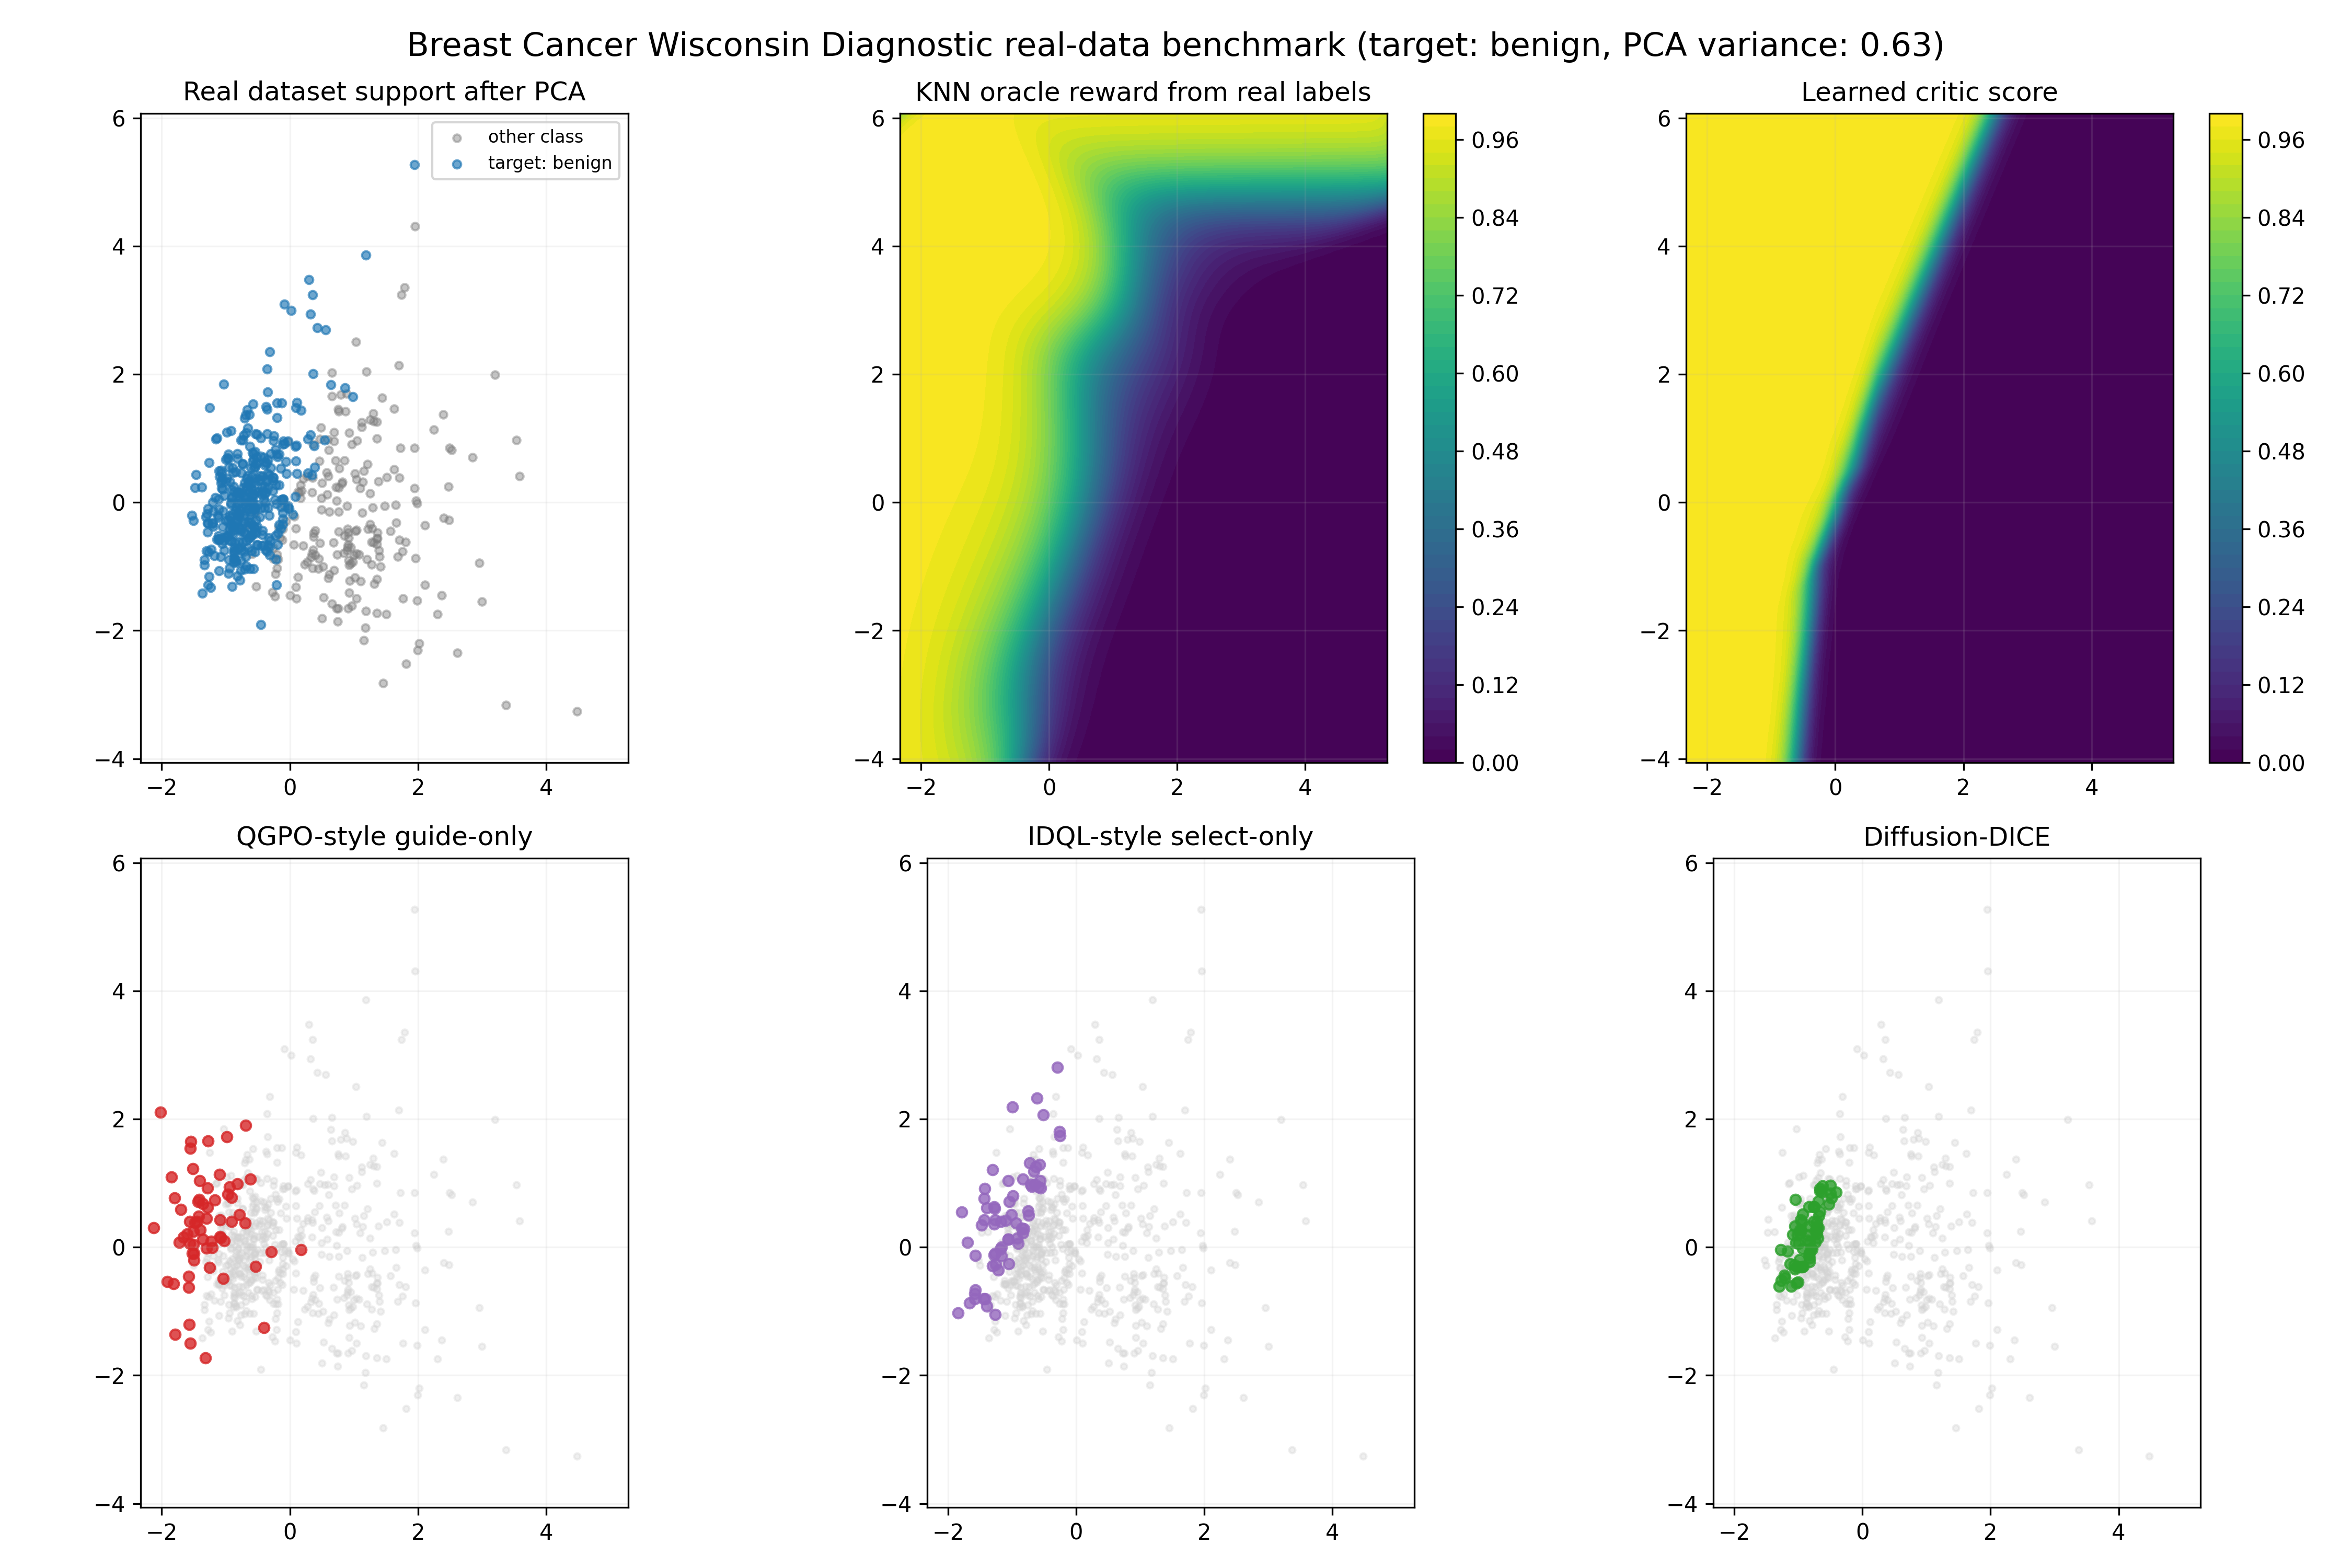

[{'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 2.0,
  'num_actions': 64,
  'id_ratio': 0.953125,
  'ood_ratio': 0.046875,
  'oracle_reward_mean': 0.9639191627502441,
  'critic_reward_mean': 0.9795012474060059,
  'target_region_ratio': 1.0,
  'mean_nearest_distance': 0.1842789351940155},
 {'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'IDQL-style select-only',
  'guidance_scale': '',
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.96149742603302,
  'critic_reward_mean': 0.9995168447494507,
  'target_region_ratio': 1.0,
  'mean_nearest_distance': 0.11607791483402252},
 {'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'Diffusion-DICE',
  'guidance_scale': 1.0,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.9470471143722534,
  'critic_reward_mean': 0.9985717535018921,
  'target_region_ratio': 1.0,
  'mean_

In [2]:
breast_problem = load_real_dataset("breast_cancer", seed=config.seed)
breast_ctx = train_problem(breast_problem, config)

breast_rows = run_policy_comparison(
    breast_ctx,
    DEMO_DIR / f"real_breast_cancer_results{suffix}.png",
    DEMO_DIR / f"real_breast_cancer_metrics{suffix}.csv",
)

display(Image(filename=str(DEMO_DIR / f"real_breast_cancer_results{suffix}.png")))
breast_rows

## 3. Hyperparameter sweep trên Breast Cancer

Cell này thay đổi guidance scale `eta`. Nếu guidance quá mạnh, QGPO-style có thể rời khỏi data support; Diffusion-DICE kỳ vọng giữ `id_ratio` cao hơn nhờ in-sample guidance.


Running real-data guidance-scale sweep...

Metrics:
- QGPO-style guide-only: ID=1.000, OOD=0.000, OracleR=0.573, CriticR=0.491, TargetRegion=0.609
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.959, CriticR=0.999, TargetRegion=1.000
- QGPO-style guide-only: ID=1.000, OOD=0.000, OracleR=0.676, CriticR=0.664, TargetRegion=0.719
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.951, CriticR=0.999, TargetRegion=1.000
- QGPO-style guide-only: ID=1.000, OOD=0.000, OracleR=0.839, CriticR=0.850, TargetRegion=0.891
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.942, CriticR=0.998, TargetRegion=1.000
- QGPO-style guide-only: ID=0.953, OOD=0.047, OracleR=0.942, CriticR=0.960, TargetRegion=1.000
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.947, CriticR=0.999, TargetRegion=1.000
- QGPO-style guide-only: ID=0.734, OOD=0.266, OracleR=0.985, CriticR=1.000, TargetRegion=1.000
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.941, CriticR=0.998, TargetRegion=1.000
- QGPO-style guide-only: ID=0.51

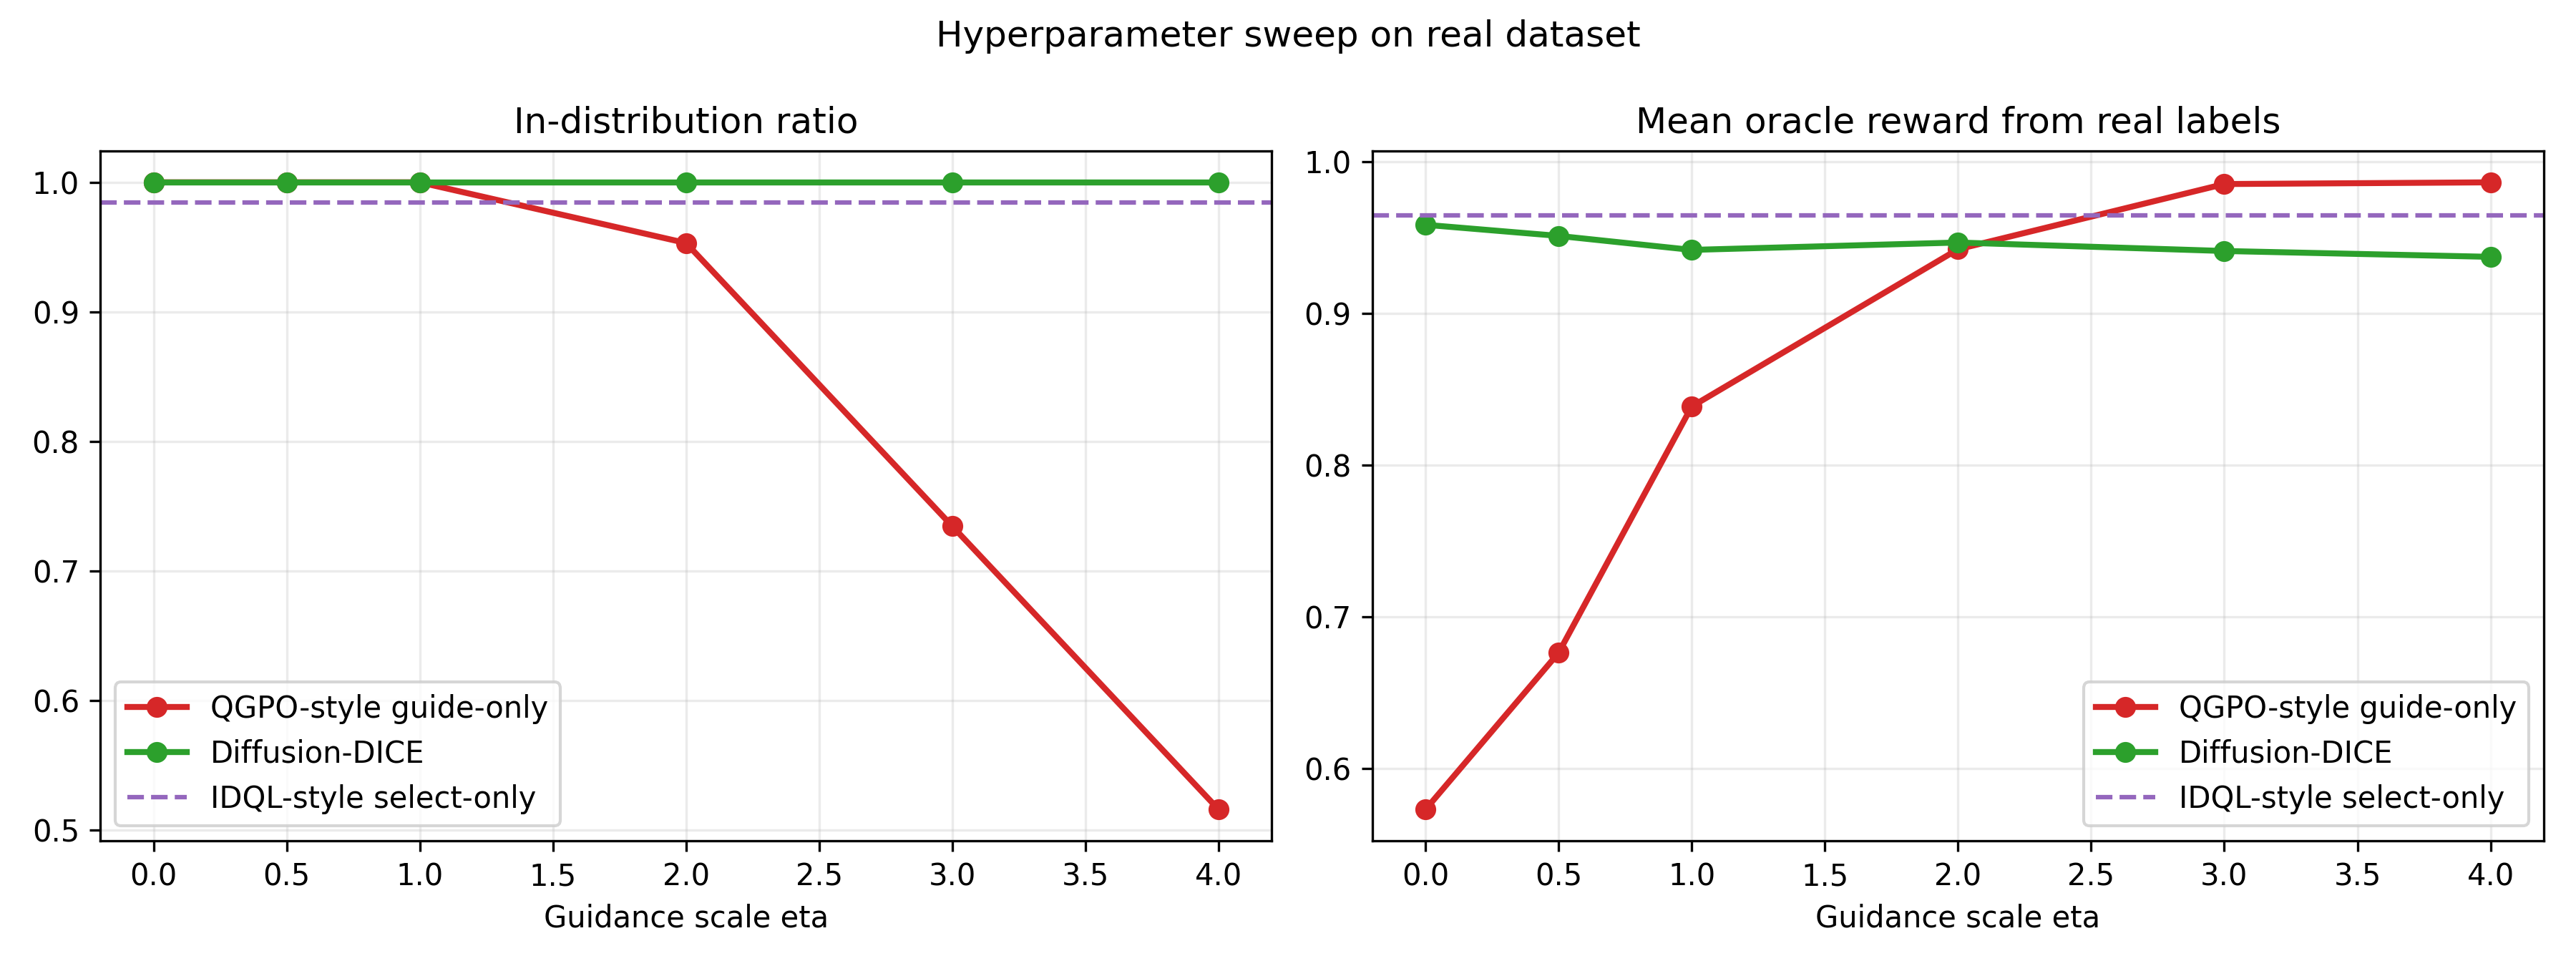

[{'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 0.0,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.5729508996009827,
  'critic_reward_mean': 0.49108898639678955,
  'target_region_ratio': 0.609375,
  'mean_nearest_distance': 0.10708707571029663},
 {'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'Diffusion-DICE',
  'guidance_scale': 0.0,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.9586145877838135,
  'critic_reward_mean': 0.9992097616195679,
  'target_region_ratio': 1.0,
  'mean_nearest_distance': 0.06626714020967484},
 {'dataset': 'breast_cancer',
  'target_class': 'benign',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 0.5,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.676315188407898,
  'critic_reward_mean': 0.6637564897537231,
  'target_region_ratio': 0.71875,
  'mea

In [3]:
breast_sweep_rows = run_guidance_sweep(
    breast_ctx,
    DEMO_DIR / f"real_breast_cancer_tuning{suffix}.png",
    DEMO_DIR / f"real_breast_cancer_tuning_metrics{suffix}.csv",
)

display(Image(filename=str(DEMO_DIR / f"real_breast_cancer_tuning{suffix}.png")))
breast_sweep_rows

## 4. Real benchmark 2: Wine Recognition

Wine Recognition là dataset thật từ UCI/sklearn. Phần này đóng vai trò mở rộng dataset: cùng một pipeline, nhưng kiểm tra trên benchmark khác.


Training on real dataset: Wine Recognition
Samples=178, target='class_0', PCA variance=0.554
Sampling IDQL-style select-only baseline...
Sampling QGPO-style guide-only baseline...
Sampling Diffusion-DICE guide-then-select method...

Metrics:
- QGPO-style guide-only: ID=0.984, OOD=0.016, OracleR=0.750, CriticR=0.831, TargetRegion=0.844
- IDQL-style select-only: ID=0.984, OOD=0.016, OracleR=0.931, CriticR=0.990, TargetRegion=1.000
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.916, CriticR=0.987, TargetRegion=1.000
Saved figure: d:\Project\ML\Project3\demo\real_wine_results_notebook.png
Saved metrics: d:\Project\ML\Project3\demo\real_wine_metrics_notebook.csv


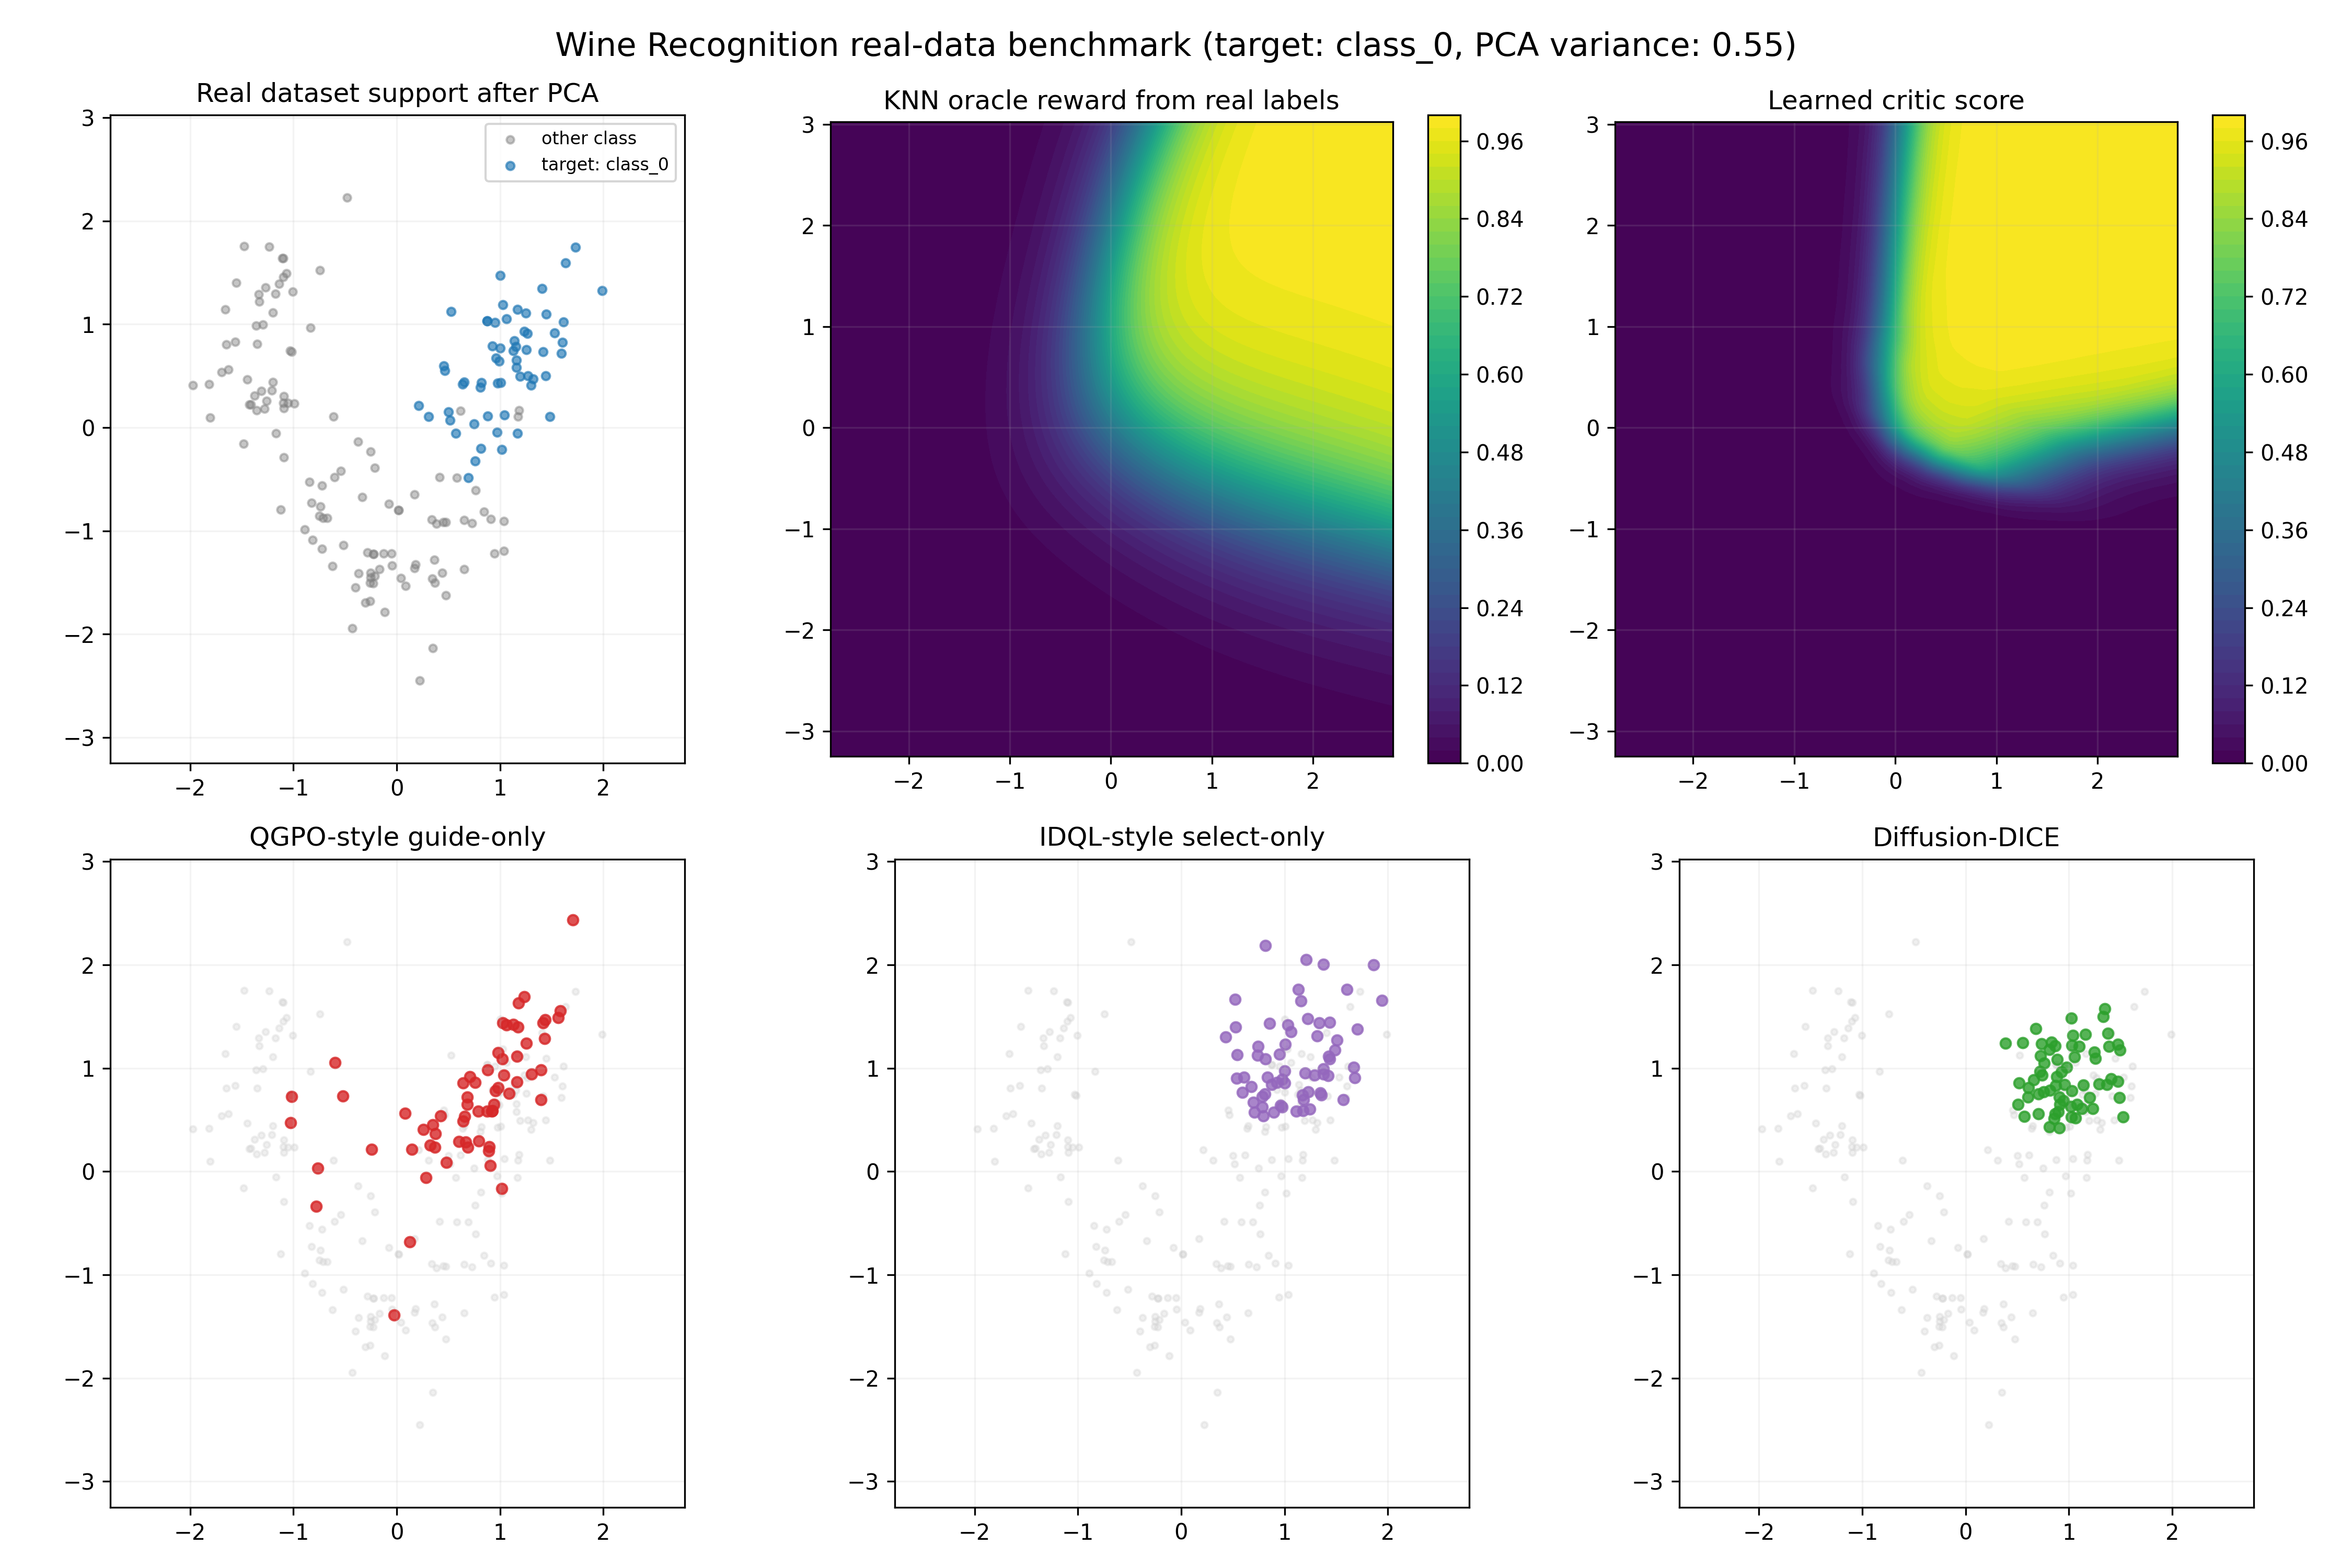

[{'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 2.0,
  'num_actions': 64,
  'id_ratio': 0.984375,
  'ood_ratio': 0.015625,
  'oracle_reward_mean': 0.7501850128173828,
  'critic_reward_mean': 0.831116259098053,
  'target_region_ratio': 0.84375,
  'mean_nearest_distance': 0.1362886279821396},
 {'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'IDQL-style select-only',
  'guidance_scale': '',
  'num_actions': 64,
  'id_ratio': 0.984375,
  'ood_ratio': 0.015625,
  'oracle_reward_mean': 0.9311916828155518,
  'critic_reward_mean': 0.9902423620223999,
  'target_region_ratio': 1.0,
  'mean_nearest_distance': 0.14986303448677063},
 {'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'Diffusion-DICE',
  'guidance_scale': 1.0,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.9155887365341187,
  'critic_reward_mean': 0.9870682954788208,
  'target_region_ratio': 1.0,
  'mean_nearest_d

In [4]:
wine_problem = load_real_dataset("wine", seed=config.seed)
wine_ctx = train_problem(wine_problem, config)

wine_rows = run_policy_comparison(
    wine_ctx,
    DEMO_DIR / f"real_wine_results{suffix}.png",
    DEMO_DIR / f"real_wine_metrics{suffix}.csv",
)

display(Image(filename=str(DEMO_DIR / f"real_wine_results{suffix}.png")))
wine_rows

## 5. Hyperparameter sweep trên Wine

Đây là phần mở rộng thứ hai: điều chỉnh siêu tham số `eta` trên dataset khác để kiểm tra độ ổn định của guidance.


Running real-data guidance-scale sweep...

Metrics:
- QGPO-style guide-only: ID=0.969, OOD=0.031, OracleR=0.312, CriticR=0.308, TargetRegion=0.328
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.899, CriticR=0.981, TargetRegion=1.000
- QGPO-style guide-only: ID=0.984, OOD=0.016, OracleR=0.483, CriticR=0.512, TargetRegion=0.516
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.924, CriticR=0.988, TargetRegion=1.000
- QGPO-style guide-only: ID=0.984, OOD=0.016, OracleR=0.517, CriticR=0.564, TargetRegion=0.547
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.931, CriticR=0.990, TargetRegion=1.000
- QGPO-style guide-only: ID=1.000, OOD=0.000, OracleR=0.704, CriticR=0.770, TargetRegion=0.781
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.929, CriticR=0.991, TargetRegion=1.000
- QGPO-style guide-only: ID=0.969, OOD=0.031, OracleR=0.847, CriticR=0.931, TargetRegion=0.938
- Diffusion-DICE: ID=1.000, OOD=0.000, OracleR=0.919, CriticR=0.988, TargetRegion=1.000
- QGPO-style guide-only: ID=0.96

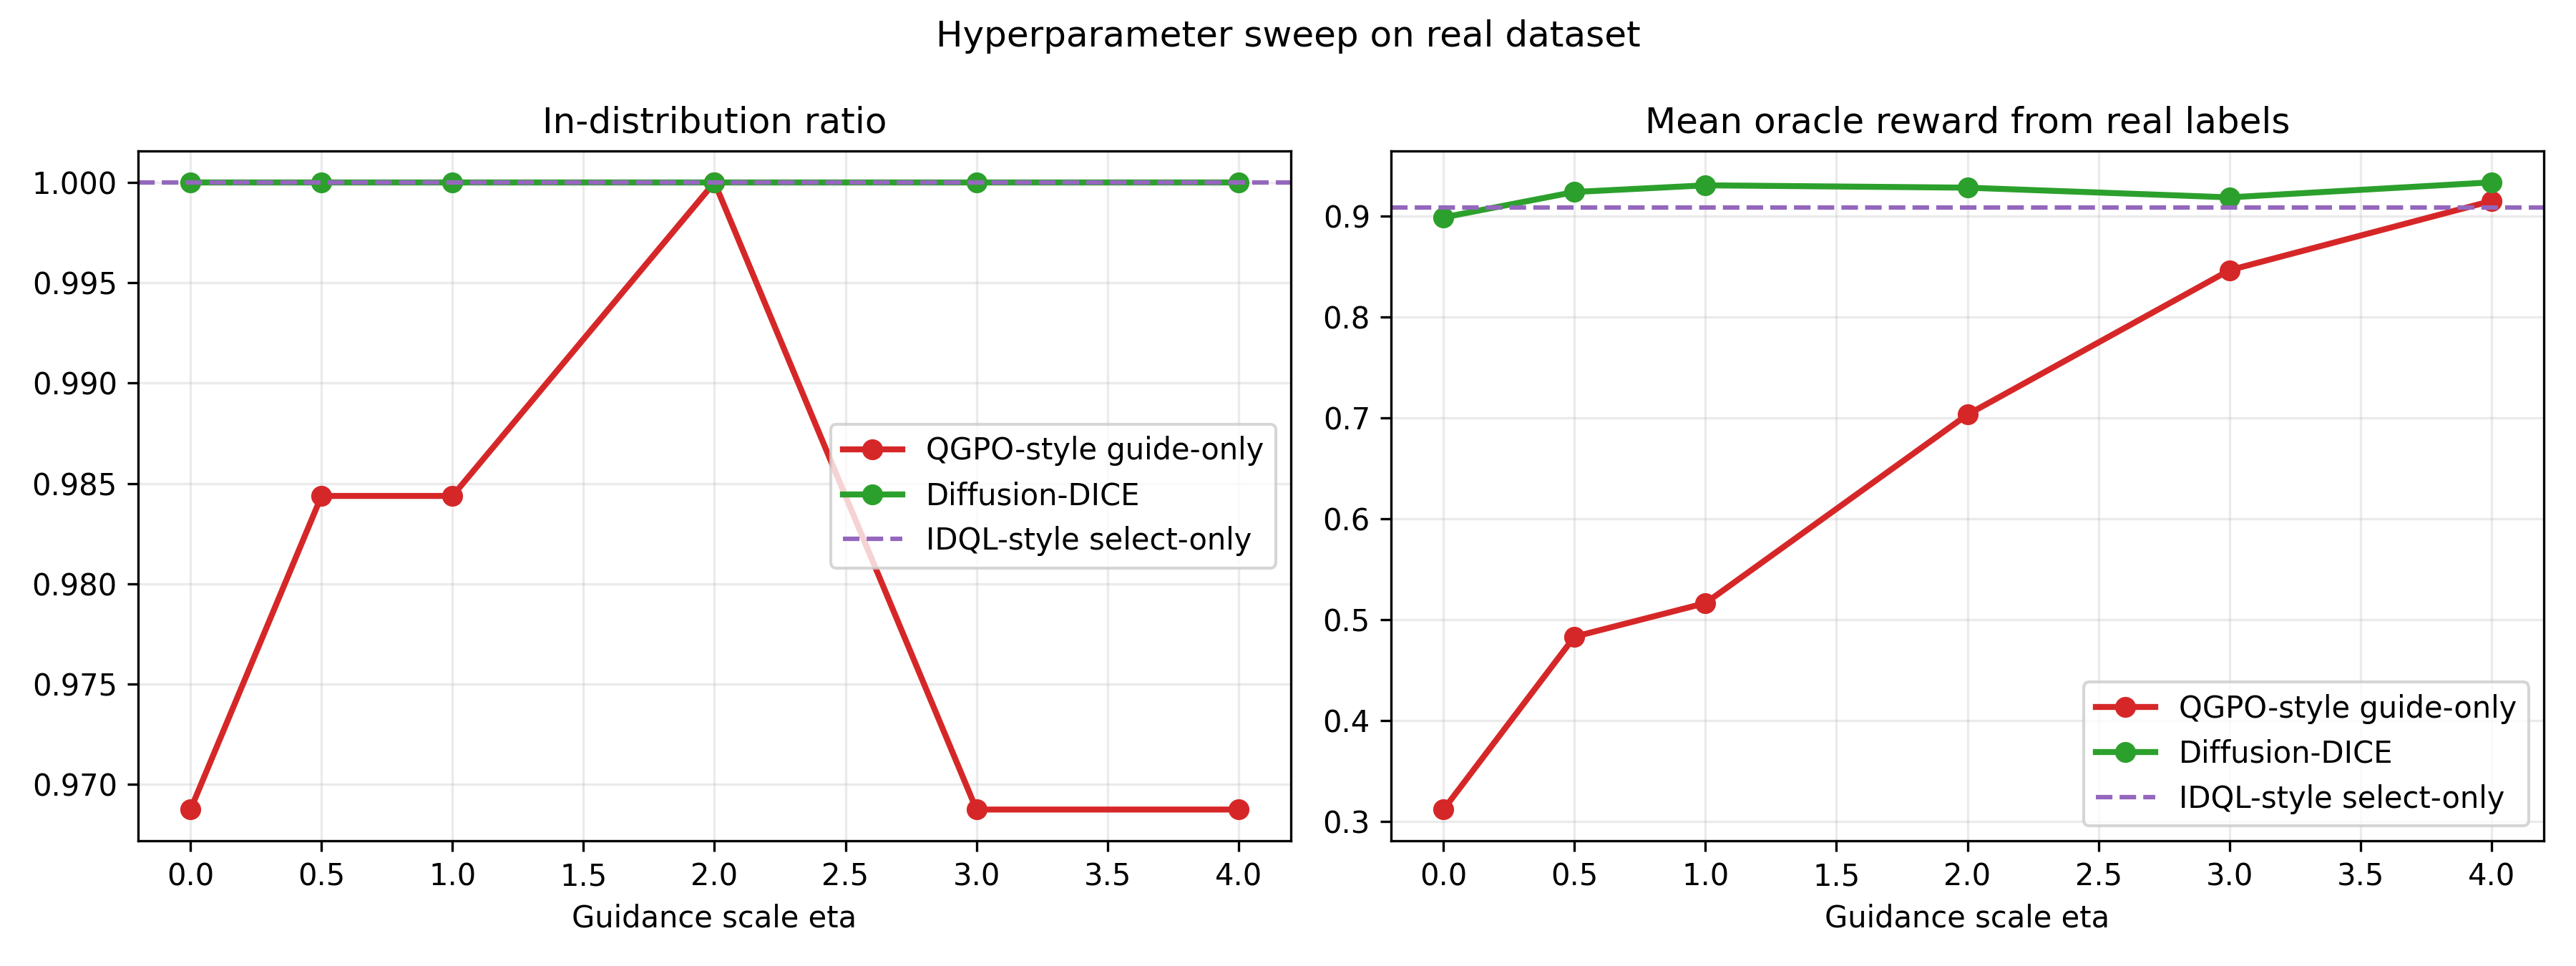

[{'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 0.0,
  'num_actions': 64,
  'id_ratio': 0.96875,
  'ood_ratio': 0.03125,
  'oracle_reward_mean': 0.312065452337265,
  'critic_reward_mean': 0.3078746795654297,
  'target_region_ratio': 0.328125,
  'mean_nearest_distance': 0.1453576385974884},
 {'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'Diffusion-DICE',
  'guidance_scale': 0.0,
  'num_actions': 64,
  'id_ratio': 1.0,
  'ood_ratio': 0.0,
  'oracle_reward_mean': 0.8990527391433716,
  'critic_reward_mean': 0.9813199043273926,
  'target_region_ratio': 1.0,
  'mean_nearest_distance': 0.09285490214824677},
 {'dataset': 'wine',
  'target_class': 'class_0',
  'method': 'QGPO-style guide-only',
  'guidance_scale': 0.5,
  'num_actions': 64,
  'id_ratio': 0.984375,
  'ood_ratio': 0.015625,
  'oracle_reward_mean': 0.48341071605682373,
  'critic_reward_mean': 0.5123671889305115,
  'target_region_ratio': 0.515625,
  'mean_near

In [5]:
wine_sweep_rows = run_guidance_sweep(
    wine_ctx,
    DEMO_DIR / f"real_wine_tuning{suffix}.png",
    DEMO_DIR / f"real_wine_tuning_metrics{suffix}.csv",
)

display(Image(filename=str(DEMO_DIR / f"real_wine_tuning{suffix}.png")))
wine_sweep_rows

## 6. Cách đọc hình và metric

- Panel trái hàng trên: real dataset sau PCA 2D, cho thấy data support.
- Panel giữa hàng trên: oracle reward suy ra từ nhãn thật bằng KNN smoothing.
- Panel phải hàng trên: learned critic score.
- Ba panel hàng dưới: action được sinh bởi QGPO-style, IDQL-style, và Diffusion-DICE.
- `id_ratio` cao nghĩa là action vẫn nằm gần real data support.
- `oracle_reward_mean` cao nghĩa là action nằm gần vùng target class theo nhãn thật.
- Nếu `critic_reward_mean` cao nhưng `id_ratio` thấp, đó là dấu hiệu critic exploitation.